# Part 1

In [78]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import welch
from scipy.ndimage import convolve1d
from sklearn.model_selection import KFold


plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 120

## 1) Visualize and preprocess the data for subject 2 (use only the first exercise set:  S2_A1_E1 with 12 actions). Does the data look reasonable? Did you need to remove any trials?

a) load the data

In [4]:
# Path to your parquet file
path = "data/s2/S2_A1_E1.parquet"

df = pd.read_parquet(path)

print(df.shape)
df.head()

(100686, 36)


,emg_0,emg_1,emg_2,emg_3,emg_4,emg_5,emg_6,emg_7,emg_8,emg_9,...,glove_16,glove_17,glove_18,glove_19,glove_20,glove_21,repetition_0,rerepetition_0,stimulus_0,restimulus_0
0,0.0269,0.1001,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,...,108.0,94.0,153.0,136.0,145.0,107.0,0,0,0,0
1,0.0269,0.0757,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,...,108.0,94.0,153.0,136.0,145.0,107.0,0,0,0,0
2,0.0317,0.0586,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,...,108.0,94.0,153.0,136.0,145.0,107.0,0,0,0,0
3,0.0293,0.0391,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,0.0024,...,108.0,94.0,153.0,136.0,145.0,107.0,0,0,0,0
4,0.0293,0.0269,0.0024,0.0024,0.0049,0.0024,0.0024,0.0024,0.0024,0.0024,...,108.0,94.0,153.0,136.0,145.0,107.0,0,0,0,0


In [6]:
print(df.columns.tolist())

['emg_0', 'emg_1', 'emg_2', 'emg_3', 'emg_4', 'emg_5', 'emg_6', 'emg_7', 'emg_8', 'emg_9', 'glove_0', 'glove_1', 'glove_2', 'glove_3', 'glove_4', 'glove_5', 'glove_6', 'glove_7', 'glove_8', 'glove_9', 'glove_10', 'glove_11', 'glove_12', 'glove_13', 'glove_14', 'glove_15', 'glove_16', 'glove_17', 'glove_18', 'glove_19', 'glove_20', 'glove_21', 'repetition_0', 'rerepetition_0', 'stimulus_0', 'restimulus_0']


b) Preprocess data

In [7]:
emg_cols   = [c for c in df.columns if c.startswith("emg_")]
glove_cols = [c for c in df.columns if c.startswith("glove_")]

emg        = df[emg_cols].to_numpy()
glove      = df[glove_cols].to_numpy()

stimulus      = df["stimulus_0"].to_numpy().astype(int)
restimulus    = df["restimulus_0"].to_numpy().astype(int)
repetition    = df["repetition_0"].to_numpy().astype(int)
rerepetition  = df["rerepetition_0"].to_numpy().astype(int)

n_samples, n_channels = emg.shape
print(f"EMG shape: {emg.shape}, glove shape: {glove.shape}")


EMG shape: (100686, 10), glove shape: (100686, 22)


In [11]:
fs = 100 
t = np.arange(n_samples) / fs
print(f"Approx recording duration: {t[-1]:.1f} s")

Approx recording duration: 1006.9 s


## 1. Quick sanity plots (raw EMG + glove)

### 1a. EMG channels over a short window

Text(0.5, 1.02, 'Raw EMG, 5 s window')

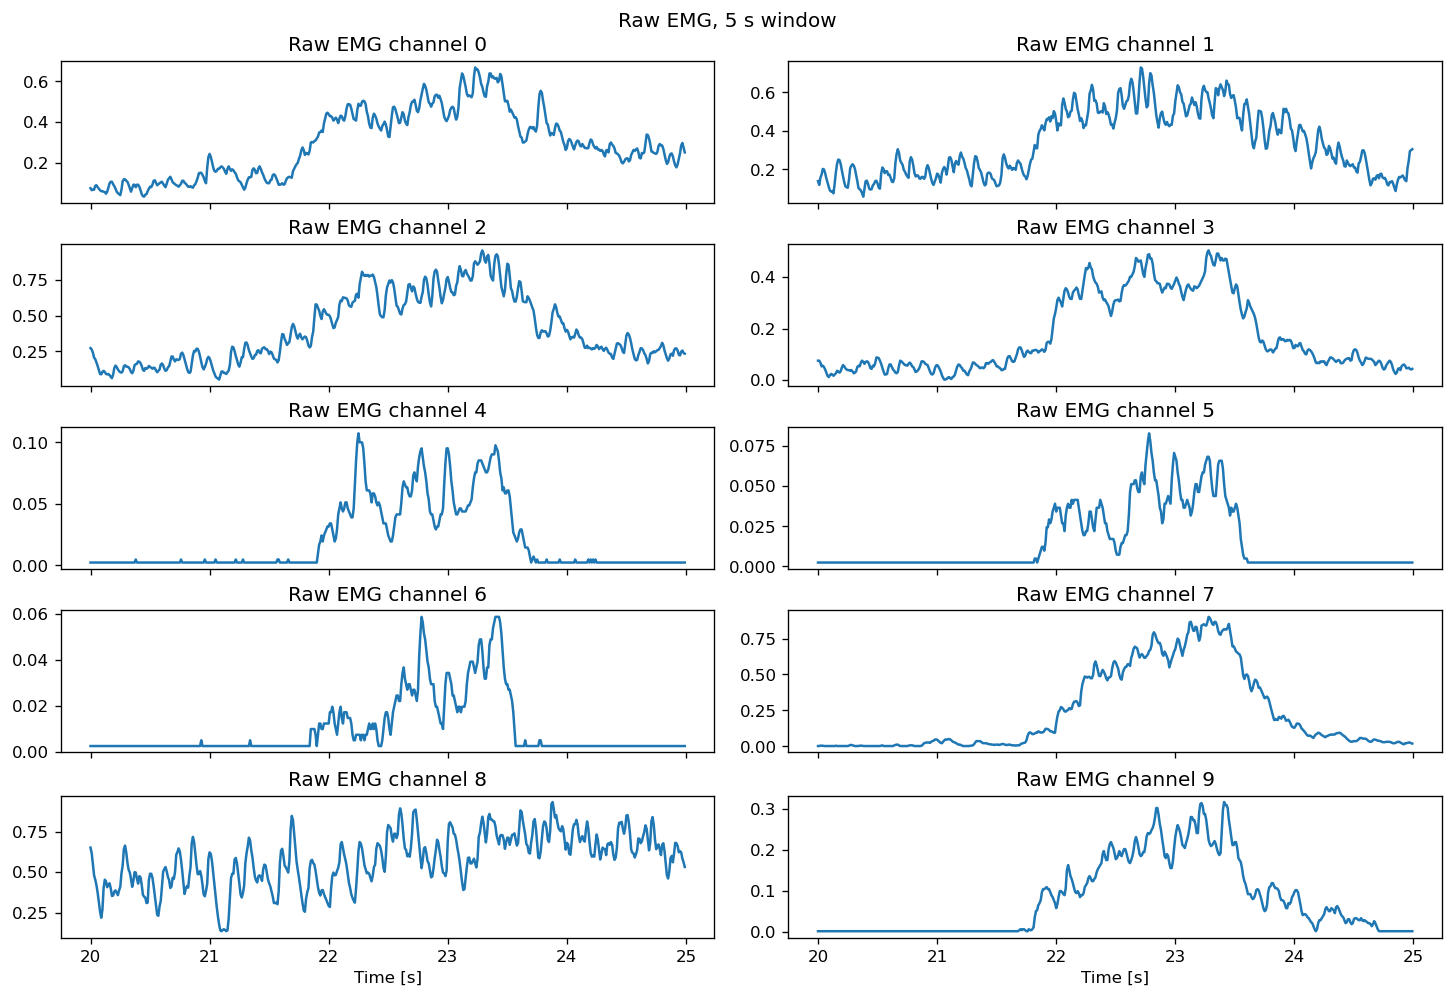

In [12]:
# pick a 5 s window somewhere in the middle
window_duration = 5  # seconds
start_time = 20      # seconds (you can change this)
start_idx = int(start_time * fs)
end_idx   = int((start_time + window_duration) * fs)
end_idx   = min(end_idx, n_samples)

segment_t   = t[start_idx:end_idx]
segment_emg = emg[start_idx:end_idx, :]

fig, ax = plt.subplots(5, 2, sharex=True, figsize=(12, 8), constrained_layout=True)
ax = ax.ravel()

for ch in range(n_channels):
    ax[ch].plot(segment_t, segment_emg[:, ch])
    ax[ch].set_title(f"Raw EMG channel {ch}")
    if ch >= 8:
        ax[ch].set_xlabel("Time [s]")

fig.suptitle("Raw EMG, 5 s window", y=1.02)


### 1b. A few glove sensors in the same window

Text(0.5, 1.02, 'Glove signals, same 5 s window')

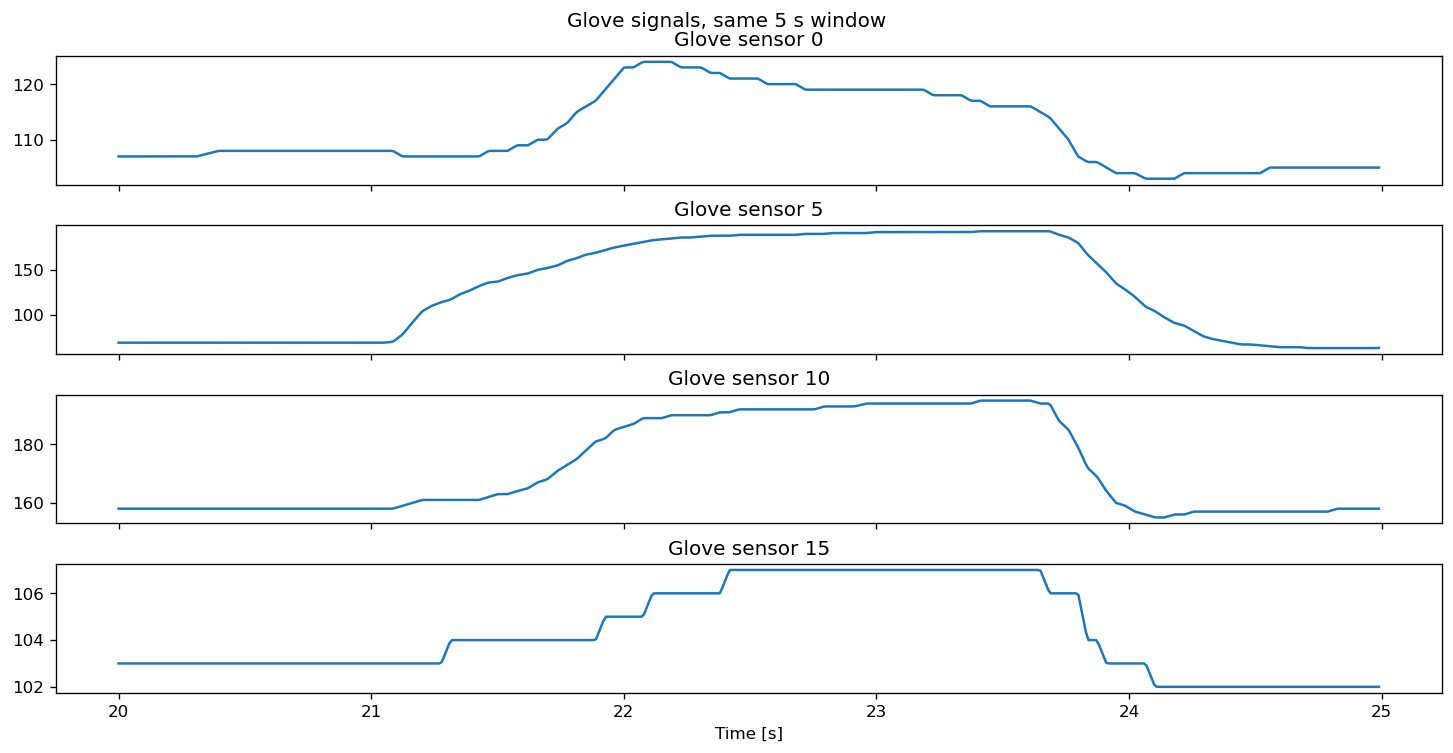

In [14]:
segment_glove = glove[start_idx:end_idx, :]

fig, ax = plt.subplots(4, 1, sharex=True, figsize=(12, 6), constrained_layout=True)

for i, gch in enumerate([0, 5, 10, 15]):
    ax[i].plot(segment_t, segment_glove[:, gch])
    ax[i].set_title(f"Glove sensor {gch}")
ax[-1].set_xlabel("Time [s]")

fig.suptitle("Glove signals, same 5 s window", y=1.02)


## 2. What preprocessing is already done for this dataset?

Otto Bock electrodes:

1) amplified (14'000)
2) band-pass filtered (range: TODO)
3) RMS-recitfied EMG 
4) internal shielding & filtering against 50-60 Hz power supply, mobile phones, etc.  

### 2a. Check for 50 Hz artifacts

Text(0.5, 1.05, 'Power spectral density – check for 50 Hz artifact')

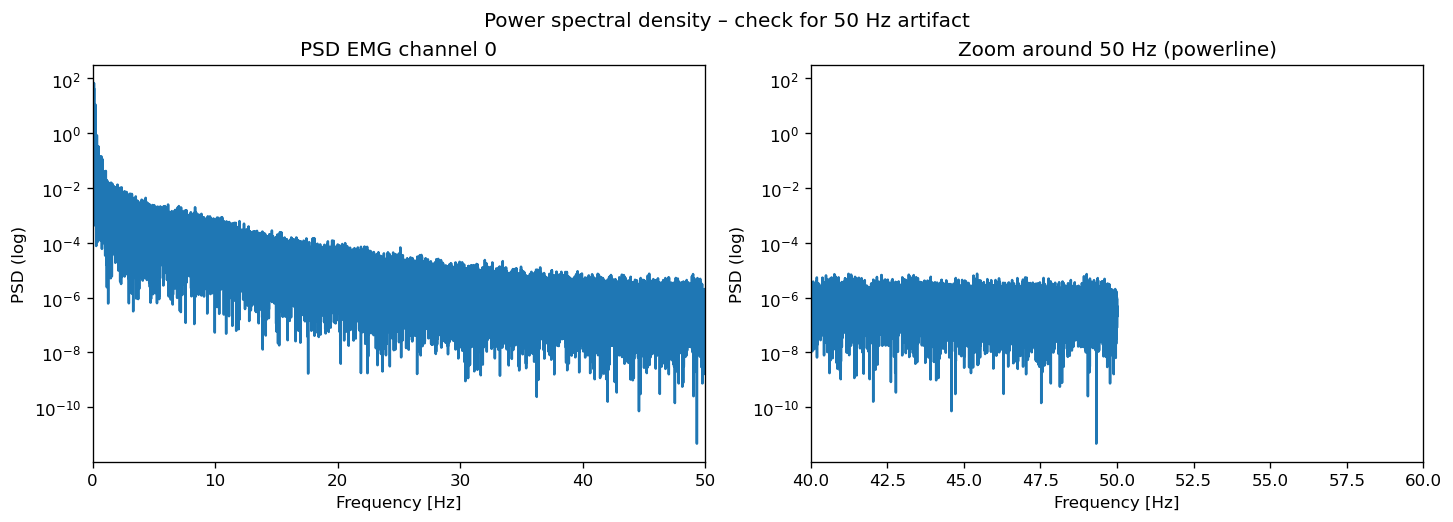

In [15]:
from scipy.signal import welch

channel_for_psd = 0  # you can change this

f, Pxx = welch(emg[:, channel_for_psd], fs=fs, nperseg=len(emg))

fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# Full band 0–50 Hz (fs/2)
ax[0].semilogy(f, Pxx)
ax[0].set_xlim(0, fs / 2)
ax[0].set_xlabel("Frequency [Hz]")
ax[0].set_ylabel("PSD (log)")
ax[0].set_title(f"PSD EMG channel {channel_for_psd}")

# Zoom around 50 Hz
ax[1].semilogy(f, Pxx)
ax[1].set_xlim(40, 60)
ax[1].set_xlabel("Frequency [Hz]")
ax[1].set_ylabel("PSD (log)")
ax[1].set_title("Zoom around 50 Hz (powerline)")

fig.suptitle("Power spectral density – check for 50 Hz artifact", y=1.05)


### 2b. Check that it's rectified (can already see above)

Global min / max per channel:
[0.0024 0.0024 0.0024 0.0024 0.0024 0.     0.     0.0024 0.     0.0024]
[3.8647 2.1606 1.3599 2.9883 0.5298 0.6421 0.5298 2.8076 4.6606 2.0508]


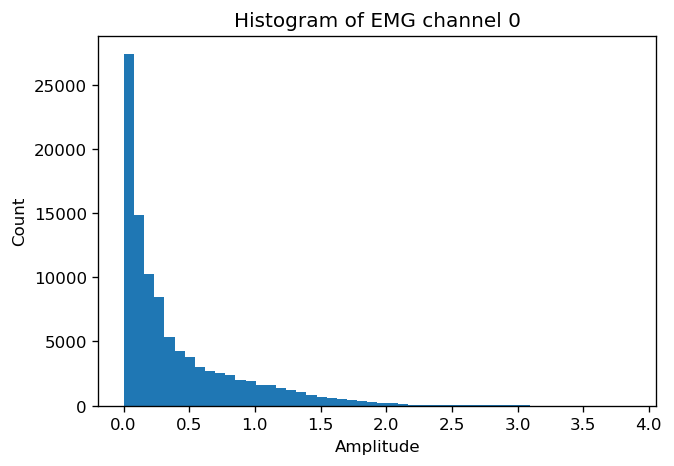

In [16]:
print("Global min / max per channel:")
print(np.min(emg, axis=0))
print(np.max(emg, axis=0))

plt.figure(figsize=(6,4))
plt.hist(emg[:, 0], bins=50)
plt.title("Histogram of EMG channel 0")
plt.xlabel("Amplitude")
plt.ylabel("Count")
plt.show()


### 3. Understand trial structure

In [18]:
unique_restim = np.unique(restimulus)
print("Unique restimulus labels:", unique_restim)

actions = unique_restim[unique_restim > 0]  # exclude rest (0)
print(f"Number of actions (excluding rest): {len(actions)}")

unique_reps = np.unique(rerepetition)
unique_reps = unique_reps[unique_reps > 0]
print("Unique rerepetition labels:", unique_reps)
print(f"Number of repetitions (excluding 0): {len(unique_reps)}")

n_stimuli     = len(actions)
n_repetitions = len(unique_reps)
samples_per_trial = np.zeros((n_stimuli, n_repetitions), dtype=int)

for i, a in enumerate(actions):
    for j, r in enumerate(unique_reps):
        idx = (restimulus == a) & (rerepetition == r)
        samples_per_trial[i, j] = idx.sum()

samples_per_trial



Unique restimulus labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
Number of actions (excluding rest): 12
Unique rerepetition labels: [ 1  2  3  4  5  6  7  8  9 10]
Number of repetitions (excluding 0): 10


array([[307, 390, 262, 226, 418, 204, 196, 270, 306, 489],
       [334, 323, 344, 309, 333, 376, 362, 307, 348, 339],
       [465, 352, 450, 460, 436, 389, 323, 388, 383, 316],
       [310, 402, 357, 396, 255, 333, 263, 369, 438, 471],
       [516, 382, 425, 379, 463, 411, 387, 343, 286, 377],
       [337, 319, 337, 368, 338, 336, 268, 354, 319, 313],
       [428, 392, 341, 393, 421, 445, 342, 328, 329, 358],
       [289, 372, 406, 397, 498, 336, 415, 328, 472, 405],
       [384, 424, 371, 316, 280, 314, 342, 284, 307, 421],
       [311, 296, 299, 296, 301, 246, 213, 317, 493, 221],
       [352, 403, 338, 416, 330, 355, 313, 322, 329, 219],
       [270, 330, 300, 387, 295, 204, 363, 267, 281, 329]])

Looks correct (trial length do differ a lot but I hope that's fine)

### 4a. Visual trial inspection

In [19]:
def plot_trial_emg(action_id, rep_id, signal=None, title_prefix="EMG"):
    if signal is None:
        signal = emg
        
    idx = (restimulus == action_id) & (rerepetition == rep_id)
    trial = signal[idx, :]
    if trial.size == 0:
        print("No samples for this (action, repetition).")
        return
    
    n_ch = trial.shape[1]
    rows, cols = 5, 2  # for 10 channels
    
    fig, ax = plt.subplots(rows, cols, figsize=(12, 8), constrained_layout=True, sharex=True)
    ax = ax.ravel()
    
    for ch in range(n_ch):
        ax[ch].plot(trial[:, ch])
        ax[ch].set_title(f"ch {ch}")
    for k in range(n_ch, rows * cols):
        ax[k].axis("off")
    
    fig.suptitle(f"{title_prefix} – action {action_id}, repetition {rep_id}", y=1.02)


Manually check a few

actions[0]: first non-zero restimulus label (first of 12 movements)

unique_reps[0]: repetition 1

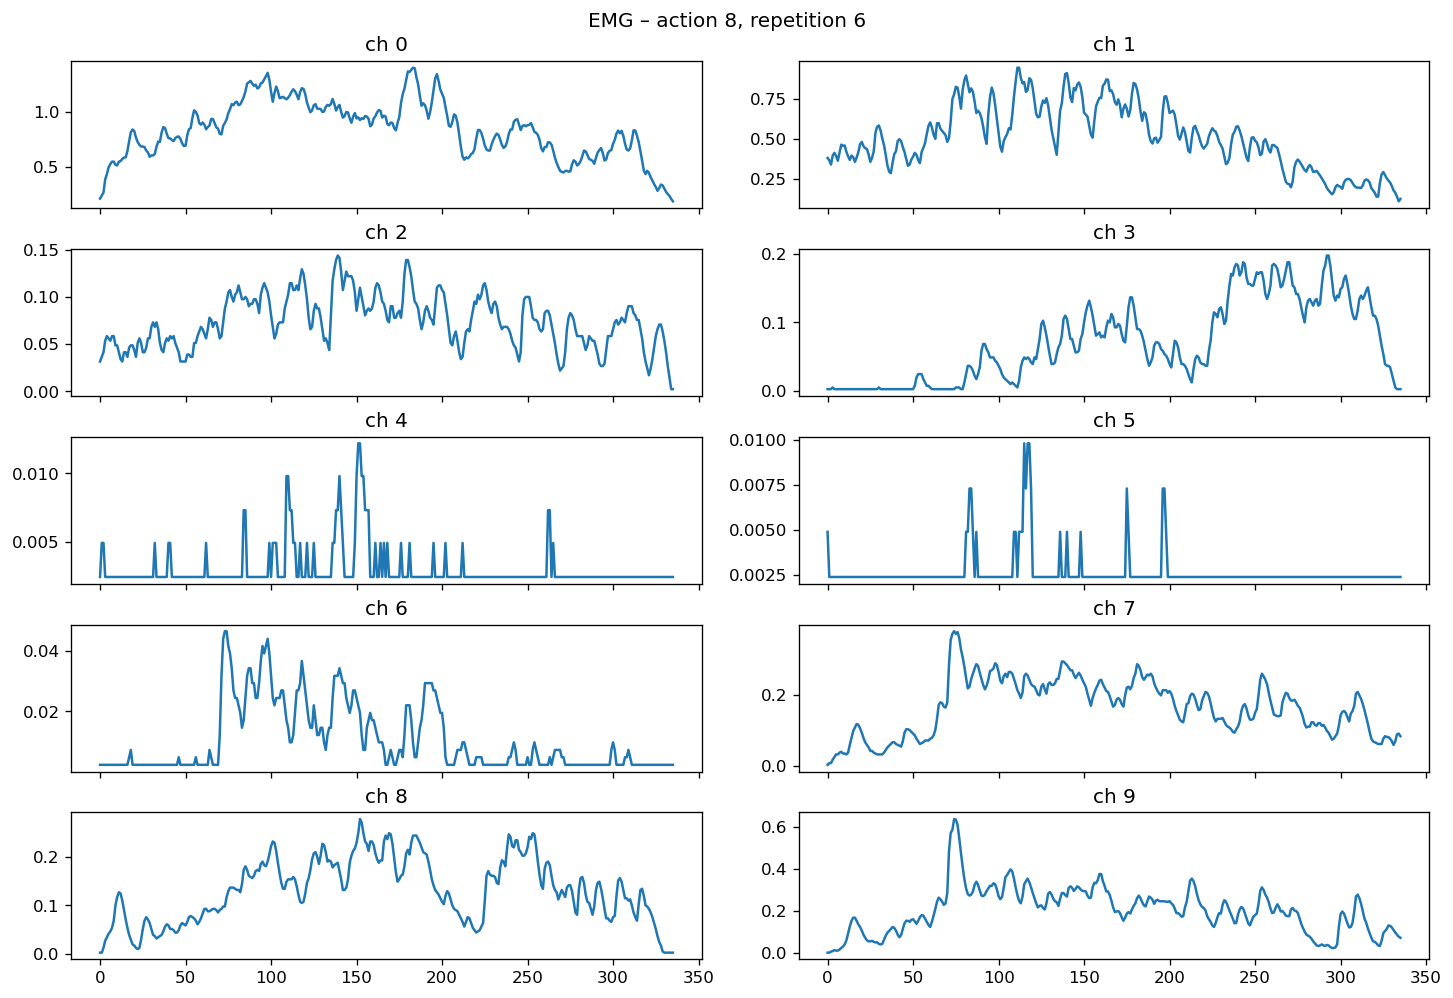

In [62]:
# Example: first action, first repetition
plot_trial_emg(action_id=actions[7], rep_id=unique_reps[5])


### 4b. Visual trial inspection (same scale)

In [22]:
def plot_trial_emg_same_scale(action_id, rep_id, signal=None, title_prefix="EMG"):
    if signal is None:
        signal = emg

    # Select trial samples
    idx = (restimulus == action_id) & (rerepetition == rep_id)
    trial = signal[idx, :]
    if trial.size == 0:
        print("No samples for this (action, repetition).")
        return

    n_ch = trial.shape[1]
    rows, cols = 5, 2

    # Compute global y-limits across all channels
    y_min = trial.min()
    y_max = trial.max()

    fig, ax = plt.subplots(rows, cols, figsize=(12, 8), constrained_layout=True, sharex=True, sharey=True)
    ax = ax.ravel()

    for ch in range(n_ch):
        ax[ch].plot(trial[:, ch])
        ax[ch].set_title(f"ch {ch}")
        ax[ch].set_ylim(y_min, y_max)  # same scale for all plots

    # Hide unused subplots (for generality)
    for k in range(n_ch, rows * cols):
        ax[k].axis("off")

    fig.suptitle(f"{title_prefix} (same y-scale) – action {action_id}, repetition {rep_id}", y=1.02)


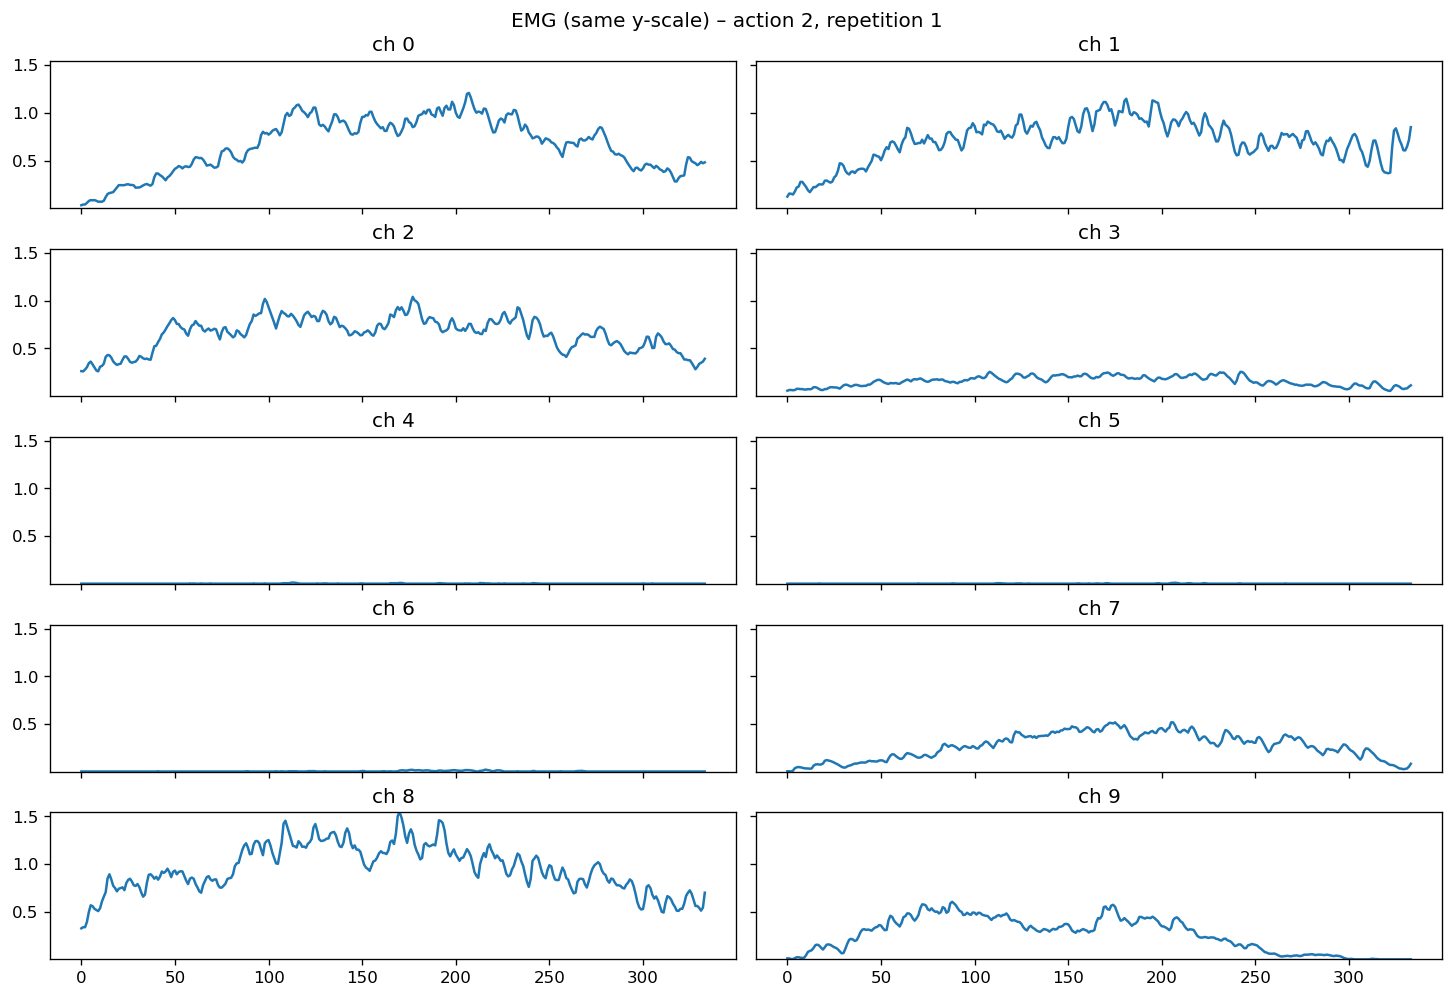

In [23]:
plot_trial_emg_same_scale(action_id=actions[1], rep_id=unique_reps[0])

Check the last one (maybe some sensor lost contact)

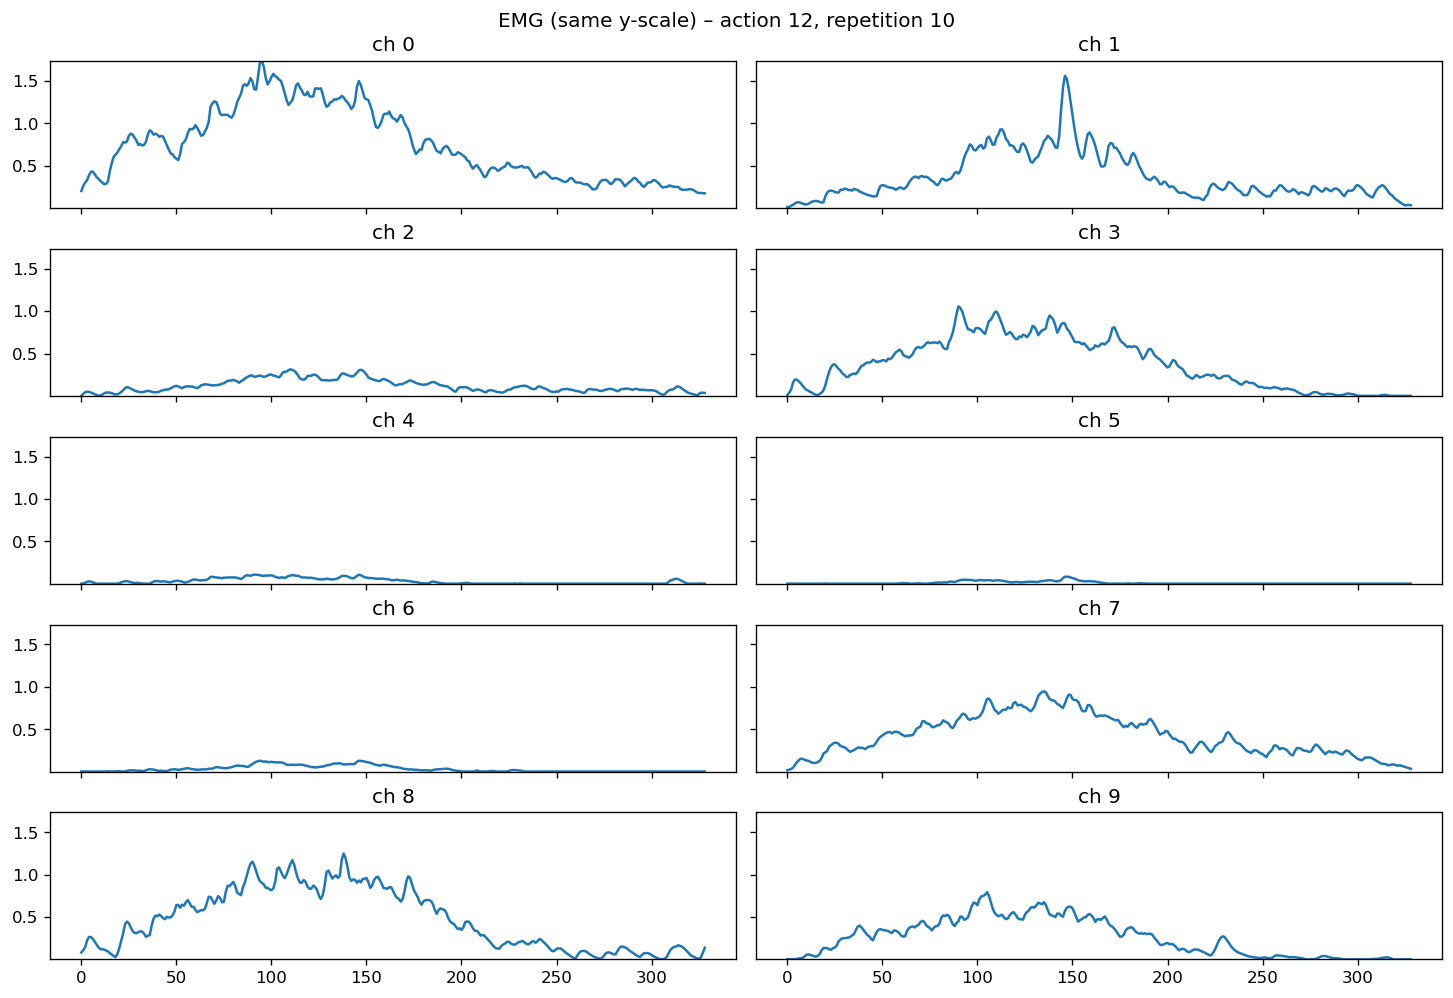

In [40]:
plot_trial_emg_same_scale(action_id=actions[11], rep_id=unique_reps[9])

Doing this manually is kind of tedious and I ain't doing that

12 actions, 10 repetitions --> 120 plots 

### 5a. Automatic detection

In [25]:
def find_bad_trials(
    signal, 
    restimulus, 
    rerepetition, 
    actions, 
    reps, 
    rms_drop_fraction=0.1, 
    min_std=1e-7
):
    """
    Flag (action, repetition) trials where one or more channels are basically 'dead':
      - very low RMS compared to typical (global RMS), and/or
      - almost zero variance.

    Parameters
    ----------
    signal : np.ndarray
        EMG array of shape (N_samples, N_channels).
    restimulus, rerepetition : np.ndarray
        Label vectors.
    actions, reps : array-like
        Unique action and repetition labels (exclude 0).
    rms_drop_fraction : float
        Trial RMS must be at least this fraction of global RMS, otherwise it's suspicious.
    min_std : float
        Absolute minimum standard deviation to avoid being considered 'flat'.

    Returns
    -------
    bad_trials : list of dict
        Each dict has keys: 'action', 'repetition', 'bad_channels', 'trial_length'.
    """
    bad_trials = []

    # Global RMS per channel over the full recording
    global_rms = np.sqrt(np.mean(signal**2, axis=0))

    for a in actions:
        for r in reps:
            idx = (restimulus == a) & (rerepetition == r)
            trial = signal[idx, :]
            if trial.size == 0:
                continue

            # Trial-level RMS and std per channel
            trial_rms = np.sqrt(np.mean(trial**2, axis=0))
            trial_std = trial.std(axis=0)

            # Conditions for 'bad' channels
            low_amp = trial_rms < (rms_drop_fraction * global_rms)
            flat    = trial_std < min_std

            bad_ch = np.where(low_amp | flat)[0]

            if len(bad_ch) > 0:
                bad_trials.append({
                    "action": int(a),
                    "repetition": int(r),
                    "bad_channels": bad_ch.tolist(),
                    "trial_length": int(trial.shape[0])
                })

    return bad_trials


In [66]:
bad_trials = find_bad_trials(
    signal=emg,
    restimulus=restimulus,
    rerepetition=rerepetition,
    actions=actions,
    reps=unique_reps,
    rms_drop_fraction=0.2,  # ~10% of normal RMS
    min_std=1e-7          # almost flat
)

print(f"Number of suspicious trials: {len(bad_trials)}")
bad_trials[:40]  # show first few


Number of suspicious trials: 37


[{'action': 2, 'repetition': 1, 'bad_channels': [4, 6], 'trial_length': 334},
 {'action': 2, 'repetition': 2, 'bad_channels': [4], 'trial_length': 323},
 {'action': 2,
  'repetition': 3,
  'bad_channels': [4, 5, 6],
  'trial_length': 344},
 {'action': 2,
  'repetition': 4,
  'bad_channels': [4, 5, 6],
  'trial_length': 309},
 {'action': 2, 'repetition': 5, 'bad_channels': [4, 6], 'trial_length': 333},
 {'action': 2,
  'repetition': 6,
  'bad_channels': [4, 5, 6],
  'trial_length': 376},
 {'action': 2,
  'repetition': 7,
  'bad_channels': [4, 5, 6],
  'trial_length': 362},
 {'action': 2,
  'repetition': 8,
  'bad_channels': [4, 5, 6],
  'trial_length': 307},
 {'action': 2,
  'repetition': 9,
  'bad_channels': [4, 5, 6],
  'trial_length': 348},
 {'action': 2,
  'repetition': 10,
  'bad_channels': [4, 5, 6],
  'trial_length': 339},
 {'action': 3, 'repetition': 8, 'bad_channels': [6], 'trial_length': 388},
 {'action': 3, 'repetition': 9, 'bad_channels': [6], 'trial_length': 383},
 {'action

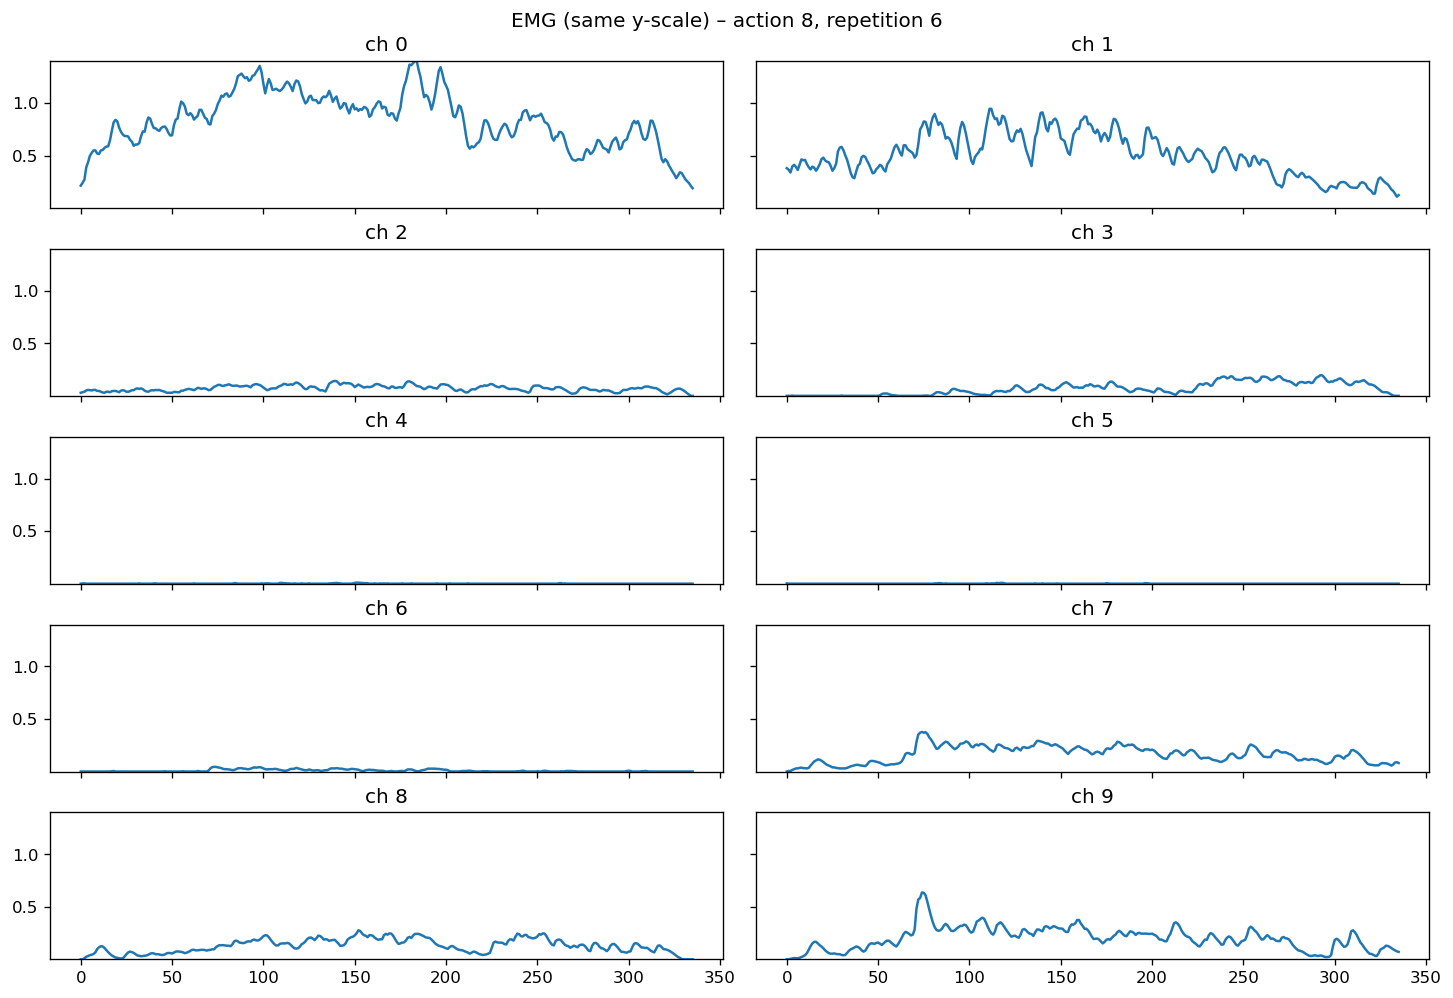

In [58]:
plot_trial_emg_same_scale(action_id=actions[7], rep_id=unique_reps[5])

### 5b. Exclude those bad channels (only that action of course)

In [68]:
# 1) Turn bad_trials into a set of (action, repetition) pairs
trials_to_drop = {(b["action"], b["repetition"]) for b in bad_trials}
print("Trials to drop (action, repetition):", sorted(trials_to_drop))

# 2) Build a sample-wise mask: keep everything *except* those trials
def build_keep_mask(restimulus, rerepetition, trials_to_drop):
    mask = np.ones_like(restimulus, dtype=bool)
    for (a, r) in trials_to_drop:
        mask &= ~((restimulus == a) & (rerepetition == r))
    return mask

keep_mask = build_keep_mask(restimulus, rerepetition, trials_to_drop)

print("Original samples:", len(df))
print("Samples after dropping:", keep_mask.sum())

# 3) New cleaned DataFrame
df_clean = df[keep_mask].reset_index(drop=True)

# 4) Re-derive cleaned arrays from df_clean
emg_clean   = df_clean[emg_cols].to_numpy()
glove_clean = df_clean[glove_cols].to_numpy()

restimulus_clean   = df_clean["restimulus_0"].to_numpy().astype(int)
rerepetition_clean = df_clean["rerepetition_0"].to_numpy().astype(int)

print("Clean EMG shape:", emg_clean.shape)
print("Clean restimulus unique:", np.unique(restimulus_clean))
print("Clean rerepetition unique:", np.unique(rerepetition_clean))



Trials to drop (action, repetition): [(2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (3, 8), (3, 9), (3, 10), (4, 5), (4, 10), (5, 6), (6, 3), (6, 4), (6, 6), (8, 1), (8, 2), (8, 3), (8, 4), (8, 6), (8, 7), (8, 8), (8, 9), (8, 10), (10, 1), (10, 2), (10, 3), (10, 4), (10, 6), (10, 7), (10, 8), (10, 9), (10, 10)]
Original samples: 100686
Samples after dropping: 87934
Clean EMG shape: (87934, 10)
Clean restimulus unique: [ 0  1  3  4  5  6  7  8  9 10 11 12]
Clean rerepetition unique: [ 0  1  2  3  4  5  6  7  8  9 10]


### 6. Envelopes

In [70]:
# Number of stimuli and repetitions in the CLEANED labels
actions_clean = np.unique(restimulus_clean)
actions_clean = actions_clean[actions_clean > 0]  # exclude rest

reps_clean = np.unique(rerepetition_clean)
reps_clean = reps_clean[reps_clean > 0]          # exclude 0

n_stimuli_clean     = len(actions_clean)
n_repetitions_clean = len(reps_clean)
n_channels          = emg_clean.shape[1]

print("n_stimuli_clean:", n_stimuli_clean)
print("n_repetitions_clean:", n_repetitions_clean)

# Moving-average window (same as Exercise 10b)
mov_mean_length  = 25
mov_mean_weights = np.ones(mov_mean_length) / mov_mean_length

# Nested lists: [stimulus_idx][repetition_idx]
emg_windows_clean   = [[None for _ in range(n_repetitions_clean)] for _ in range(n_stimuli_clean)]
emg_envelopes_clean = [[None for _ in range(n_repetitions_clean)] for _ in range(n_stimuli_clean)]

for s_idx, a in enumerate(actions_clean):
    for r_idx, r in enumerate(reps_clean):
        # select this trial in the CLEANED data
        idx = (restimulus_clean == a) & (rerepetition_clean == r)
        trial = emg_clean[idx, :]
        if trial.size == 0:
            continue

        emg_windows_clean[s_idx][r_idx]   = trial
        emg_envelopes_clean[s_idx][r_idx] = convolve1d(trial, mov_mean_weights, axis=0)


n_stimuli_clean: 11
n_repetitions_clean: 10


Quickly look at envelope for one trial

Text(0.5, 0.98, 'Envelopes of the EMG signal')

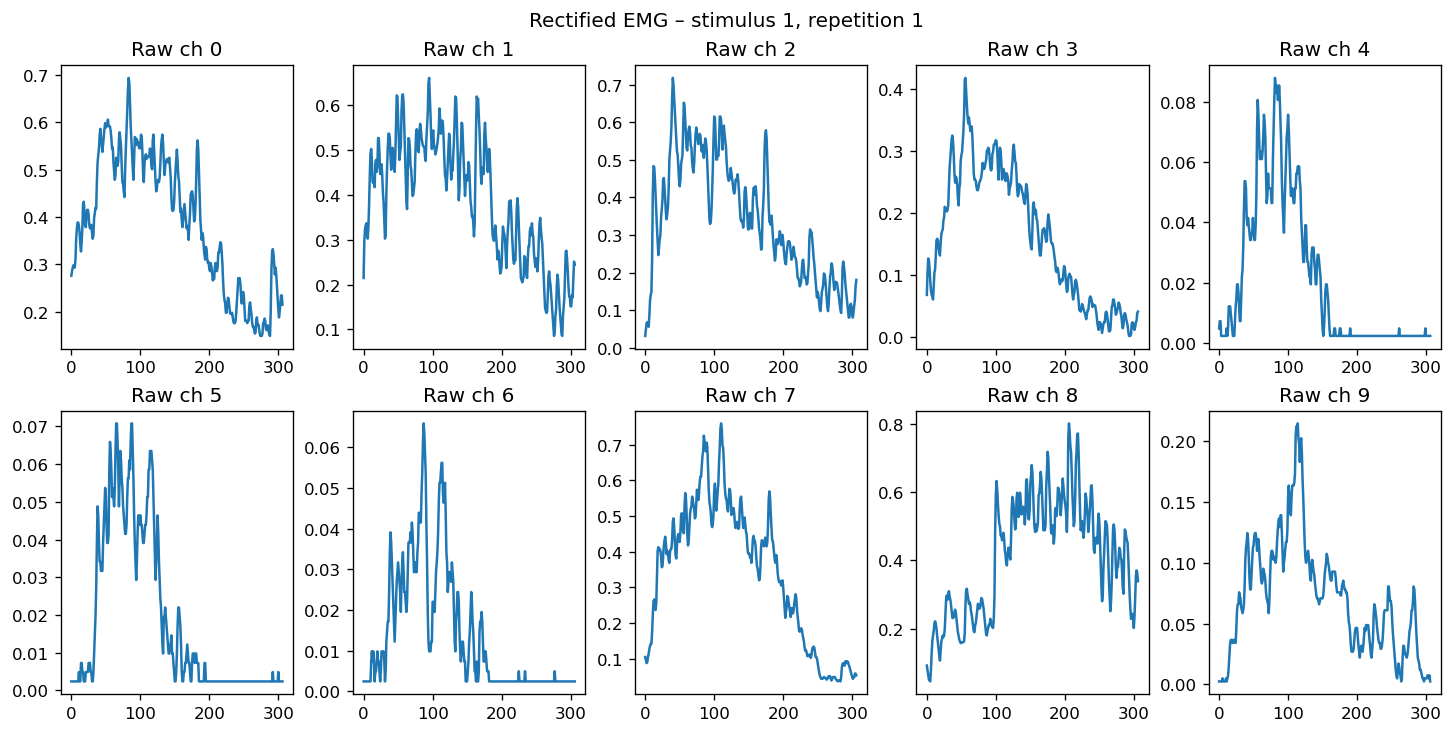

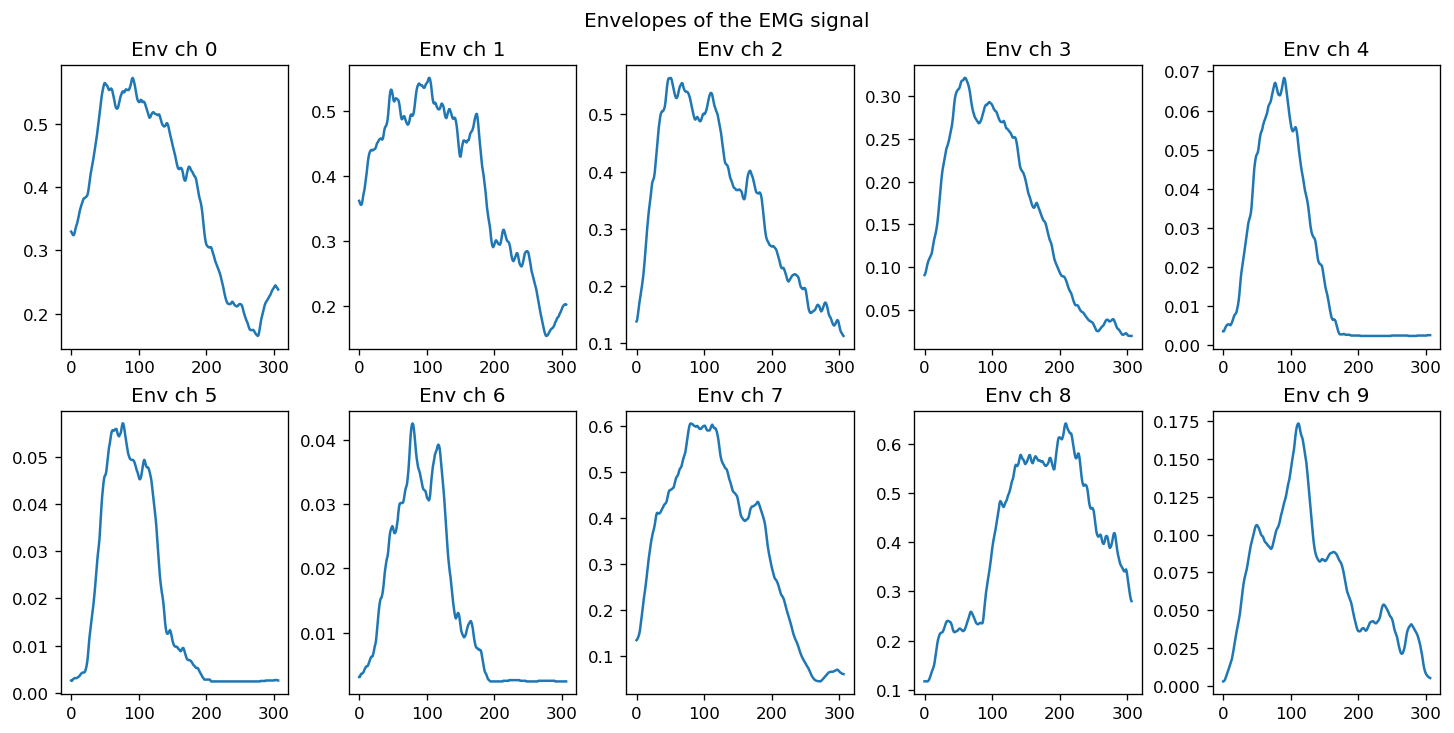

In [71]:
example_s_idx = 0  # first stimulus in actions_clean
example_r_idx = 0  # first repetition in reps_clean

trial_raw  = emg_windows_clean[example_s_idx][example_r_idx]
trial_env  = emg_envelopes_clean[example_s_idx][example_r_idx]

fig, ax = plt.subplots(2, 5, figsize=(12, 6), constrained_layout=True)
ax = ax.ravel()

for ch in range(n_channels):
    ax[ch].plot(trial_raw[:, ch])
    ax[ch].set_title(f"Raw ch {ch}")
plt.suptitle(f"Rectified EMG – stimulus {actions_clean[example_s_idx]}, repetition {reps_clean[example_r_idx]}")

fig, ax = plt.subplots(2, 5, figsize=(12, 6), constrained_layout=True)
ax = ax.ravel()
for ch in range(n_channels):
    ax[ch].plot(trial_env[:, ch])
    ax[ch].set_title(f"Env ch {ch}")
plt.suptitle("Envelopes of the EMG signal")


### 7 Average activations + heatmaps

In [72]:
import seaborn as sns
sns.set()

# (channels, stimuli, repetitions)
emg_average_activations_clean = np.full(
    (n_channels, n_stimuli_clean, n_repetitions_clean),
    np.nan
)

for s_idx in range(n_stimuli_clean):
    for r_idx in range(n_repetitions_clean):
        env = emg_envelopes_clean[s_idx][r_idx]
        if env is None:
            continue
        emg_average_activations_clean[:, s_idx, r_idx] = np.mean(env, axis=0)


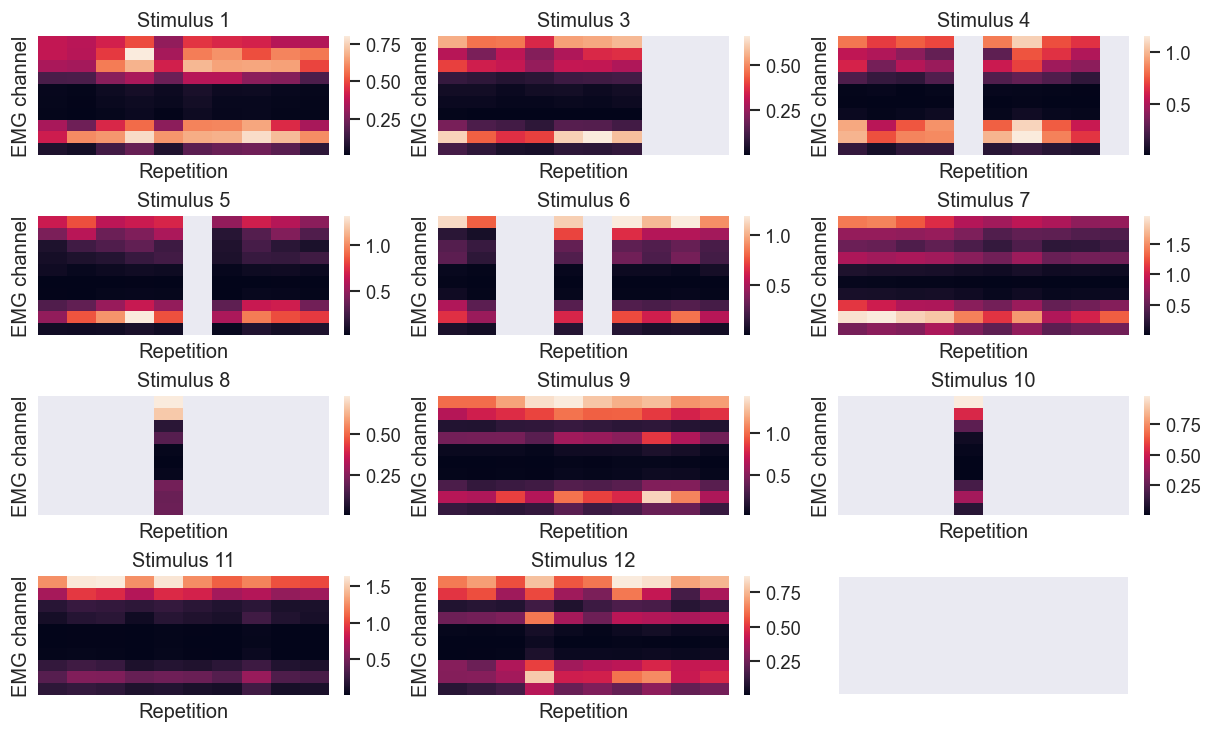

In [73]:
fig, ax = plt.subplots(4, 3, figsize=(10, 6), constrained_layout=True, sharex=True, sharey=True)
ax = ax.ravel()

for s_idx in range(n_stimuli_clean):
    sns.heatmap(
        emg_average_activations_clean[:, s_idx, :],
        ax=ax[s_idx],
        xticklabels=False,
        yticklabels=False,
        cbar=True
    )
    ax[s_idx].set_title(f"Stimulus {actions_clean[s_idx]}")
    ax[s_idx].set_xlabel("Repetition")
    ax[s_idx].set_ylabel("EMG channel")


TODO: only one repetition bad is weird, no?

## 2. Split the data into training, validation, and testing sets for the subject. Why do we need the different datasets? 

Things to keep in mind

- Stratified (The split should be stratified, meaning that all classes (movement labels) appear in train/validation/test in similar proportions.)

- We will fix a random seed to make the split reproducible.

- assign whole repetitions to each set, not individual windows (DATA LEAKAGE!!)

TODO: double check this (is that what they write in the paper?)

Let's split the following way:

2 repetitions (3 and 7) for testing --> 8 left for validation and training --> 4 fold cross validation

TODO do we have to be careful because we removed some channels for certain stimuli?

In [74]:
# For reproducibility when we shuffle reps later
np.random.seed(42)

# Unique repetitions in the CLEANED data (excluding 0)
all_reps = np.unique(rerepetition_clean)
all_reps = all_reps[all_reps > 0]

print("All repetitions in cleaned data:", all_reps)

# --- Choose which repetitions are test ---
# You can change [3, 7] if you prefer different test reps,
# but keep them fixed once chosen.
test_reps = np.array([3, 7])

# Training/validation repetitions are all others
train_reps = np.array([r for r in all_reps if r not in test_reps])

print("Train repetitions:", train_reps)
print("Test repetitions: ", test_reps)

# --- Sample-wise masks (for later use) ---
train_mask = np.isin(rerepetition_clean, train_reps)
test_mask  = np.isin(rerepetition_clean, test_reps)

print("Samples in train reps:", train_mask.sum())
print("Samples in test reps: ", test_mask.sum())


All repetitions in cleaned data: [ 1  2  3  4  5  6  7  8  9 10]
Train repetitions: [ 1  2  4  5  6  8  9 10]
Test repetitions:  [3 7]
Samples in train reps: 23398
Samples in test reps:  5641


In [75]:
# Optional: train/test views of the raw signals (per sample)
emg_train = emg_clean[train_mask]
emg_test  = emg_clean[test_mask]

restimulus_train = restimulus_clean[train_mask]
restimulus_test  = restimulus_clean[test_mask]

rerepetition_train = rerepetition_clean[train_mask]
rerepetition_test  = rerepetition_clean[test_mask]


In [79]:
unique_train_reps = np.unique(train_reps)
print("Unique train reps:", unique_train_reps)

# 4-fold CV over train repetitions
kf = KFold(n_splits=4, shuffle=True, random_state=42)

# We'll store folds as lists of repetition IDs (not sample indices yet)
cv_rep_splits = []

for fold_idx, (rep_tr_idx, rep_val_idx) in enumerate(kf.split(unique_train_reps)):
    reps_in_train_fold = unique_train_reps[rep_tr_idx]
    reps_in_val_fold   = unique_train_reps[rep_val_idx]

    cv_rep_splits.append((reps_in_train_fold, reps_in_val_fold))

    print(f"Fold {fold_idx}:")
    print("  train reps:", reps_in_train_fold)
    print("  val reps  :", reps_in_val_fold)


Unique train reps: [ 1  2  4  5  6  8  9 10]
Fold 0:
  train reps: [ 1  4  5  6  9 10]
  val reps  : [2 8]
Fold 1:
  train reps: [2 4 5 6 8 9]
  val reps  : [ 1 10]
Fold 2:
  train reps: [ 1  2  5  8  9 10]
  val reps  : [4 6]
Fold 3:
  train reps: [ 1  2  4  6  8 10]
  val reps  : [5 9]


### Why we need all of that (ChatGPT) TODO

### ✅ Why do we need different datasets?

- **Training set** – used to fit the model.  
- **Validation set** – used for hyperparameter tuning and monitoring overfitting.  
- **Test set** – kept completely unseen; provides an unbiased estimate of generalization.

- **Repetition-wise splitting is essential for EMG:**  
  - Samples from the same repetition are highly correlated.  
  - Mixing repetitions across train/test causes information leakage and inflated accuracy.

- **A single split is not reliable:**  
  - Performance may vary depending on which repetitions land in each set.  
  - Cross-validation reduces this randomness.

---

### ✅ Why use cross-validation?

- Splits the training set into *k* folds.  
- Trains on *k−1* folds and validates on the remaining fold.  
- Repeats this *k* times and averages performance.

**Benefits:**

- More stable and trustworthy evaluation.  
- Helps detect overfitting.  
- Enables systematic hyperparameter tuning.  
- **Repetition-wise CV** ensures each repetition stays in exactly one fold — the correct approach for EMG data.


## 3. Extract features from the trials (at least 5 different ones), explain briefly why you picked these features. Visualize the typical values of  the features across the different trials. What do you see? Are the values similar  between repetitions and between channels? Explain the possible reasons for  similarity/discrepancies.  